In [1]:
# !pip install shap pandas numpy matplotlib seaborn scikit-learn

<!-- DATASET -->
https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset

<!-- https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?resource=download&select=male_players.csv -->

# Projekt: Przewidywanie wartości rynkowej piłkarzy (FC 24)
**Autor:** [Kamil Stępień]
**Cel:** Zbudowanie modelu regresji (ML i DL) do wyceny piłkarzy oraz wyjaśnienie wyników za pomocą SHAP.

In [2]:
# ==========================================
# 1. IMPORT BIBLIOTEK
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor  
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
print("Biblioteki załadowane pomyślnie.")

c:\Users\liusz\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Biblioteki załadowane pomyślnie.


## 2. Wczytanie i czyszczenie danych
Dane pochodzą z gry EA Sports FC 24. Zbiór zawiera ok. 18 tysięcy wierszy.
W tym kroku:
1. Wczytujemy plik CSV.
2. Wybieramy kluczowe kolumny (statystyki, wiek, potencjał).
3. **Filtrujemy dane:** Ograniczamy zbiór do profesjonalistów (`Overall > 60`), aby usunąć amatorów zaburzających model.
4. Usuwamy braki danych (piłkarze bez ceny).

In [3]:
# ==========================================
# 2. WCZYTANIE I CZYSZCZENIE DANYCH
# ==========================================
try:
    df = pd.read_csv('male_players.csv', low_memory=False)
except FileNotFoundError:
    df = pd.read_csv('data/male_players.csv', low_memory=False)

print(f"Rozmiar oryginalny: {df.shape}")

selected_columns = [
    'short_name', 'age', 'club_name', 'overall', 'potential', 'value_eur',
    'wage_eur', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'preferred_foot', 'work_rate' 
]

df = df[selected_columns]

df = df.dropna(subset=['value_eur'])
df = df[df['value_eur'] > 0]

# Ograniczenie zbioru do profesjonalistów (overall > 60), żeby usunąć szum (overall to jest ogolna ocena zawodnika w fifie, i np.
# jakis gosc z 3 ligi niemieckiej bedzie miec mniej niz 60 wiec jego nie ma po co brac pod uwage bo ich statystyki sa przeklamane)"
df = df[df['overall'] > 60]

# uzueplenienie brakow w statystykach (np. bramkarze nie mają pace/shooting)
numeric_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
df[numeric_stats] = df[numeric_stats].fillna(0)

print(f"Rozmiar po oczyszczeniu: {df.shape} ")

Rozmiar oryginalny: (180021, 109)
Rozmiar po oczyszczeniu: (138065, 15) 


## 3. Analiza Danych
Przed budową modelu musimy zrozumieć dane tak jak bylo to na zajeciach :).
Sporządzamy wykresy:
* **Rozkład ceny:** Sprawdzamy, czy jest skośny (dużo tanich graczy, mało gwiazd).
* **Zarobki:** Porównujemy budżety płacowe gigantów (Real, Barca, Man United).
* **Korelacje:** Badamy, które cechy (np. drybling, wiek) są najsilniej powiązane z ceną.

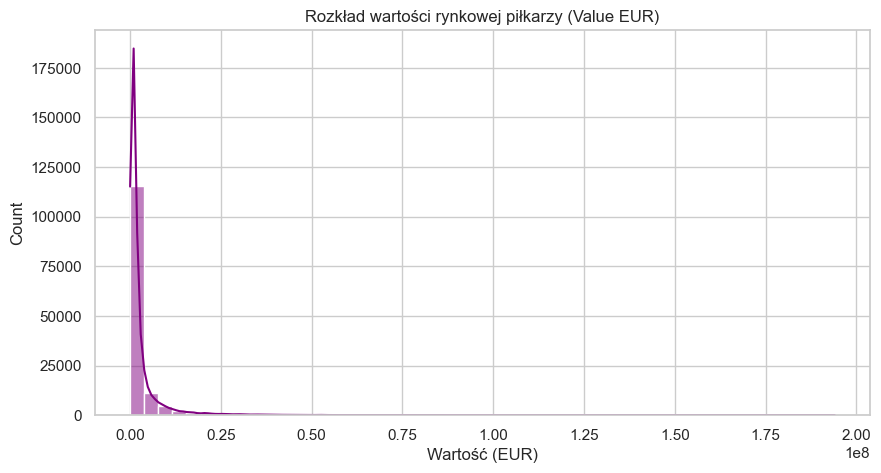

C:\Users\liusz\AppData\Local\Temp\ipykernel_15748\4245983018.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='club_name', y='wage_eur', data=df_top, palette='Set2')


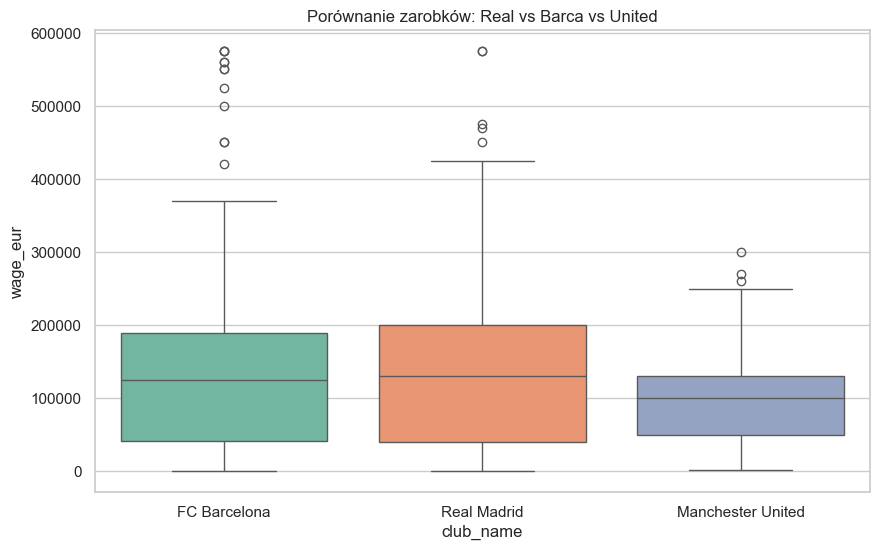

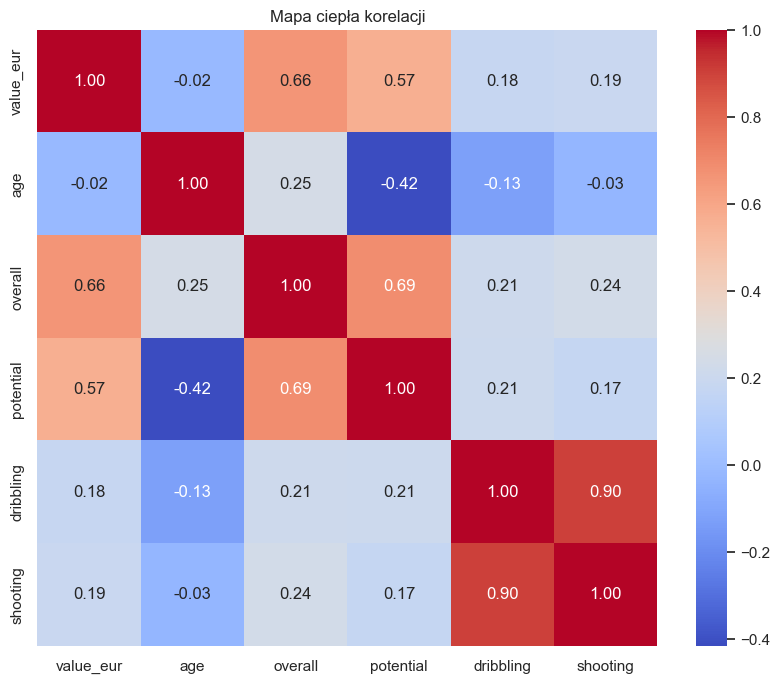

In [4]:
# ==========================================
# 3. ANALIZA DANYCH 
# ==========================================

plt.figure(figsize=(10, 5))
sns.histplot(df['value_eur'], bins=50, kde=True, color='purple')
plt.title('Rozkład wartości rynkowej piłkarzy (Value EUR)')
plt.xlabel('Wartość (EUR)')
plt.show()

teams = ['Real Madrid', 'FC Barcelona', 'Manchester United']
df_top = df[df['club_name'].isin(teams)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='club_name', y='wage_eur', data=df_top, palette='Set2')
plt.title('Porównanie zarobków: Real vs Barca vs United')
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df[['value_eur', 'age', 'overall', 'potential', 'dribbling', 'shooting']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa ciepła korelacji')
plt.show()

## 4. Preprocessing (Przygotowanie danych)
Aby modele matematyczne działały poprawnie, musimy przetworzyć dane:
1. **Podział:** Rozdzielamy cechy (X) od ceny (y) oraz zbiór treningowy od testowego.
2. **Skalowanie (`StandardScaler`):** Sprowadzamy cechy numeryczne (wiek, statystyki) do wspólnej skali. Jest to krytyczne dla sieci neuronowych.
3. **Kodowanie (`OneHotEncoder`):** Zamieniamy cechy tekstowe (noga, pracowitość) na liczby (0/1).

In [5]:
# ==========================================
# 4. PRZYGOTOWANIE DO MODELU
# ==========================================

X = df.drop(['value_eur', 'wage_eur', 'short_name', 'club_name'], axis=1)
y = df['value_eur']

categorical_features = ['preferred_foot', 'work_rate']
numeric_features = ['age', 'overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Dane przygotowane.")
print(f"Kształt danych wejściowych: {X_train_processed.shape}")

Dane przygotowane.
Kształt danych wejściowych: (110452, 20)


## 5. Machine Learning (ML) - Wybór algorytmu i parametrów
Testujemy trzy podejścia o rosnącej złożoności:
1. **Regresja Liniowa:** Prosty model bazowy (Baseline).
2. **Drzewo Decyzyjne:** Model nieliniowy.
3. **Las Losowy (Random Forest):** Zaawansowany model zespołowy.

**Optymalizacja:** Używamy `GridSearchCV`, aby automatycznie dobrać najlepsze parametry dla Lasu Losowego (liczbę drzew i ich głębokość).

In [6]:
# ==========================================
# 5. UCZENIE MASZYNOWE (ML)
# ==========================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

print("\n--- ML: Porównanie Modeli i Dobór Parametrów ---")

ml_results = {}

# ---------------------------------------------------------
# regresja liniowa
# ---------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)

r2_lr = r2_score(y_test, y_pred_lr)
ml_results['Linear Regression'] = r2_lr
print(f"1. Linear Regression R2: {r2_lr:.4f}")


# ---------------------------------------------------------
# drzewo decyzyjne
# ---------------------------------------------------------
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)

r2_dt = r2_score(y_test, y_pred_dt)
ml_results['Decision Tree'] = r2_dt
print(f"2. Decision Tree R2: {r2_dt:.4f}")


# ---------------------------------------------------------
# random forest
# ---------------------------------------------------------
print("\n3. Random Forest - Trwa dobieranie parametrów (GridSearch)...")

param_grid = {
    'n_estimators': [50, 100],        
    'max_depth': [10, 20, None],      
    'min_samples_split': [2, 5]       
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, scoring='r2', n_jobs=-1, verbose=1)

grid_search.fit(X_train_processed, y_train)

best_rf_model = grid_search.best_estimator_
print(f"   -> Najlepsze znalezione parametry: {grid_search.best_params_}")

y_pred_rf = best_rf_model.predict(X_test_processed)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

ml_results['Random Forest (Tuned)'] = r2_rf

print(f"Random Forest (Best) R2: {r2_rf:.4f}")
print(f"Random Forest (Best) RMSE: {rmse_rf:,.0f} EUR")

best_ml_model = max(ml_results, key=ml_results.get)
print(f"\nZwycięzca w kategorii ML: {best_ml_model} (R2: {ml_results[best_ml_model]:.4f})")

rf_model = best_rf_model


--- ML: Porównanie Modeli i Dobór Parametrów ---
1. Linear Regression R2: 0.4713
2. Decision Tree R2: 0.8697

3. Random Forest - Trwa dobieranie parametrów (GridSearch)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
   -> Najlepsze znalezione parametry: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest (Best) R2: 0.9343
Random Forest (Best) RMSE: 1,778,380 EUR

Zwycięzca w kategorii ML: Random Forest (Tuned) (R2: 0.9343)


## 6. Deep Learning (DL) - Porównanie architektur
**Eksperyment:** Porównujemy trzy architektury sieci:
1. **Mała:** (64 neurony) - płytka sieć.
2. **Średnia:** (128 -> 64 neurony) - standardowa.
3. **Duża:** (256 -> 128 -> 64 neurony) - głęboka sieć.

Stosujemy **Early Stopping**, aby przerwać uczenie, gdy sieć przestanie się poprawiać.


--- DL: Testowanie różnych architektur sieci neuronowych (MLP) ---
Trenowanie: Model 1 (64,)...


c:\Users\liusz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Trenowanie: Model 2 (128, 64)...
Trenowanie: Model 3 (256, 128, 64)...


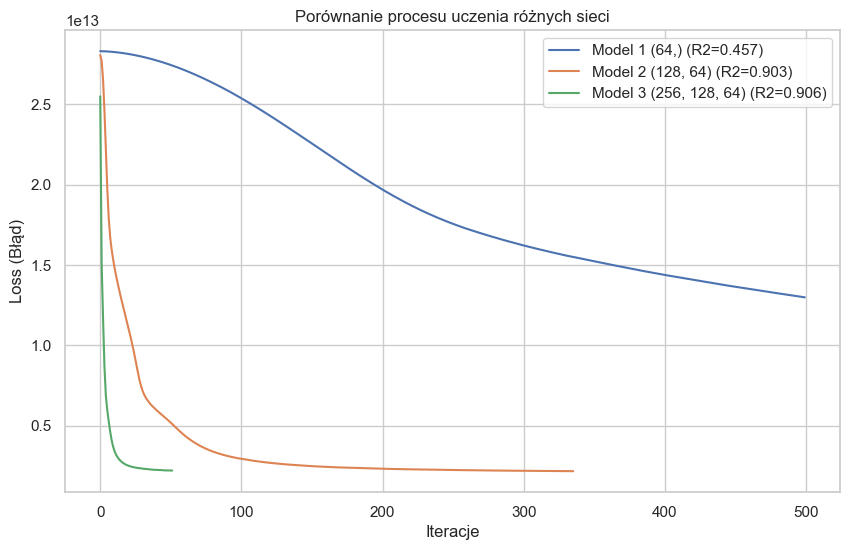


--- WYNIKI PORÓWNANIA SIECI ---
                              R2          RMSE
Model 1 (64,)           0.457464  5.109609e+06
Model 2 (128, 64)       0.902814  2.162598e+06
Model 3 (256, 128, 64)  0.905896  2.128031e+06

Najlepszy model to: Model 3 (256, 128, 64)
To ten model zostałby wybrany do finalnego wdrożenia.


In [7]:
# ==========================================
# 6. DEEP LEARNING (DL) - Porównanie Architektur
# ==========================================
print("\n--- DL: Testowanie różnych architektur sieci neuronowych (MLP) ---")
architectures = [
    (64,),              
    (128, 64),          
    (256, 128, 64)      
]

results = {} 

plt.figure(figsize=(10, 6))

for i, hidden_layers in enumerate(architectures):
    model_name = f"Model {i+1} {hidden_layers}"
    print(f"Trenowanie: {model_name}...")
    
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
    
    mlp.fit(X_train_processed, y_train)
    
    # ocenka
    y_pred = mlp.predict(X_test_processed)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[model_name] = {'R2': r2, 'RMSE': rmse}
    
    plt.plot(mlp.loss_curve_, label=f'{model_name} (R2={r2:.3f})')

plt.title('Porównanie procesu uczenia różnych sieci')
plt.xlabel('Iteracje')
plt.ylabel('Loss (Błąd)')
plt.legend()
plt.show()

print("\n--- WYNIKI PORÓWNANIA SIECI ---")
results_df = pd.DataFrame(results).T
print(results_df)

best_model_name = results_df['R2'].idxmax()
print(f"\nNajlepszy model to: {best_model_name}")
print("To ten model zostałby wybrany do finalnego wdrożenia.")

## 7. XAI - Wyjaśnialność modelu (SHAP)
Modele takie jak Random Forest są "czarnymi skrzynkami". Używamy biblioteki **SHAP**, aby zajrzeć do środka i zrozumieć:
* Które cechy najbardziej podbijają cenę?
* Jak wiek wpływa na wycenę (czy starszy = tańszy?).


--- XAI: Wyjaśnialność modelu (SHAP) ---
Generowanie wykresu SHAP...


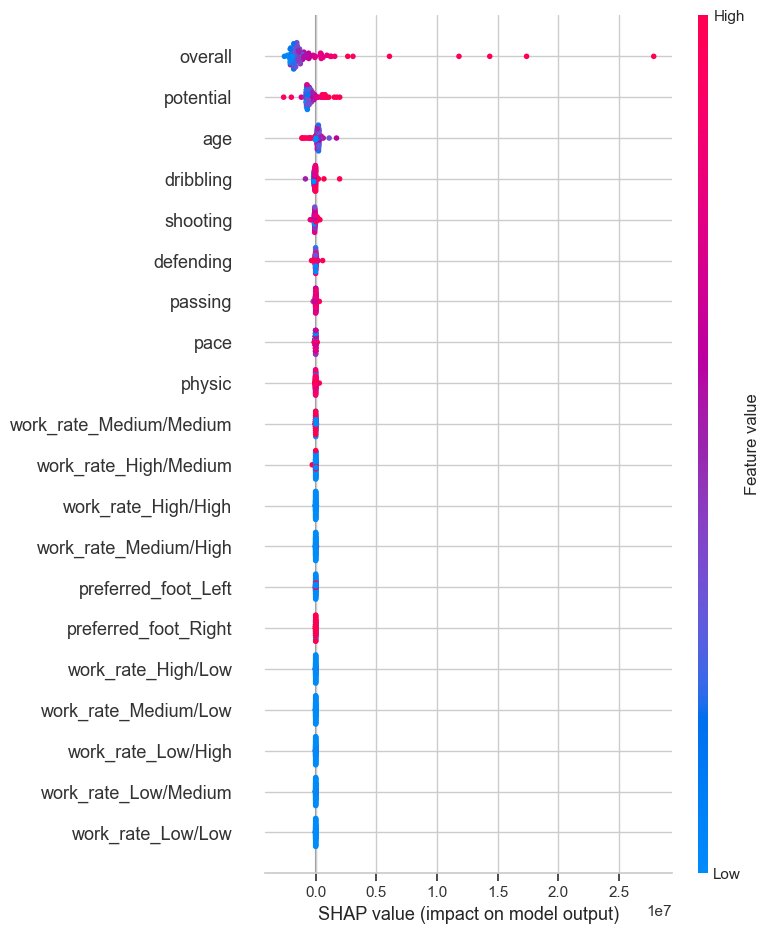

Przykład wpływu cech na wycenę konkretnego piłkarza:


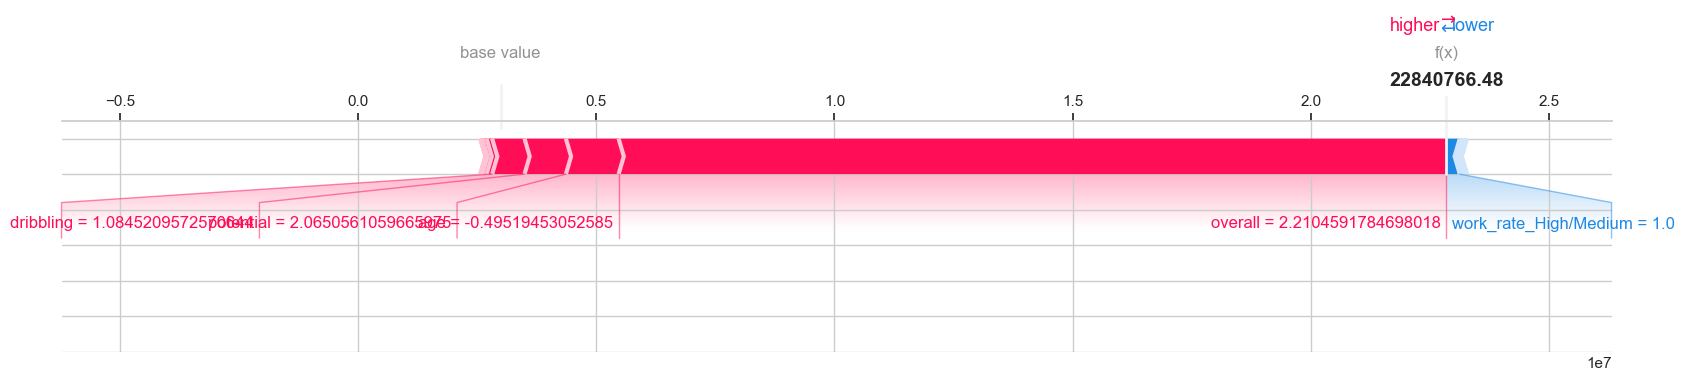

In [8]:
# ==========================================
# 7. XAI (SHAP)
# ==========================================
print("\n--- XAI: Wyjaśnialność modelu (SHAP) ---")

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_processed[:100])

feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

print("Generowanie wykresu SHAP...")
shap.summary_plot(shap_values, X_test_processed[:100], feature_names=feature_names)

print("Przykład wpływu cech na wycenę konkretnego piłkarza:")
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_processed[0,:], feature_names=feature_names, matplotlib=True)